# 01 — Análise Exploratória de Dados (EDA)

**Datathon FIAP — Fase 05** | Grupo 65

## Objetivo

Entender o dataset **Telco Customer Churn** para fundamentar as decisões da Etapa 1 (baseline) e da Etapa 2 (agente LLM com modelo de churn como tool).

## Problema de negócio

Uma operadora de telecom quer **reduzir o churn** (clientes que cancelam o serviço). Identificar antecipadamente quem está prestes a sair permite ações de retenção (descontos, upgrade de plano, contato proativo).

## O que esta EDA precisa entregar

1. Diagnóstico de qualidade dos dados (nulos, tipos, outliers)
2. Distribuição da variável-alvo (`Churn`) — saber se é problema balanceado ou desbalanceado
3. Identificação dos **principais drivers de churn** (features mais discriminantes)
4. **Mapeamento métrica de negócio → métrica técnica** — escolha justificada da métrica que vamos otimizar no modelo

---
## 1. Configuração do ambiente

Importações e configurações de visualização.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 50)

DATA_PATH = Path("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset existe? {DATA_PATH.exists()}")

Dataset existe? True


---
## 2. Carregamento e inspeção inicial

Carregamos o CSV e olhamos dimensões, tipos de dados e as primeiras linhas para ter uma visão geral.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]} linhas × {df.shape[1]} colunas")
df.head()

Shape: 7043 linhas × 21 colunas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Observações iniciais:**

- 7.043 clientes, 21 colunas
- Mix de variáveis categóricas (gender, Contract, etc.) e numéricas (tenure, MonthlyCharges)
- `customerID` é identificador único — não é feature
- `TotalCharges` aparece como `object` (string), mas deveria ser numérico — vamos tratar isso na próxima célula

---
## 3. Tratamento de tipos

`TotalCharges` é o total acumulado pago pelo cliente. Quando `tenure = 0` (cliente novíssimo, ainda não foi cobrado), o valor vem como string vazia (espaço). Precisamos converter para numérico e decidir o que fazer com esses casos.

In [4]:
# Quantos casos suspeitos?
n_blank = (df["TotalCharges"] == " ").sum()
print(f"TotalCharges em branco: {n_blank} casos")

# Confirma a hipótese — todos com tenure=0?
print(df.loc[df["TotalCharges"] == " ", "tenure"].value_counts())

TotalCharges em branco: 11 casos
tenure
0    11
Name: count, dtype: int64


In [5]:
# Conversão segura: strings inválidas viram NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Para clientes com tenure=0, TotalCharges deveria ser 0 (ou MonthlyCharges, se já houve uma cobrança parcial).
# Vamos imputar com MonthlyCharges como aproximação razoável.
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"])

print("Nulos restantes em TotalCharges:", df["TotalCharges"].isnull().sum())
print("Tipo final:", df["TotalCharges"].dtype)

Nulos restantes em TotalCharges: 0
Tipo final: float64


---
## 4. Análise da variável-alvo (Churn)

Antes de qualquer modelagem, precisamos saber **quão balanceado é o problema**. Isso vai influenciar a escolha de métrica e técnicas (oversampling, class_weight, etc.).

Distribuição de Churn:
  No: 5174 clientes (73.5%)
  Yes: 1869 clientes (26.5%)


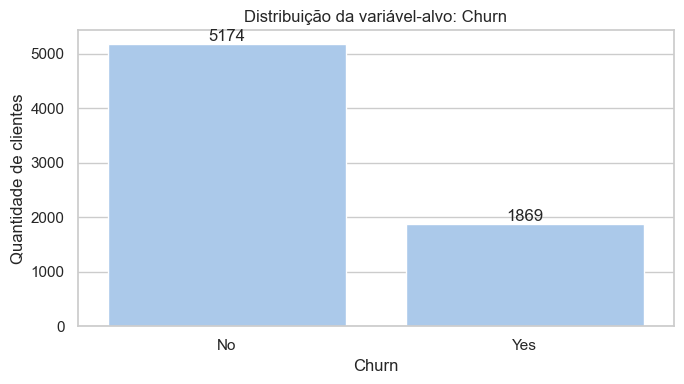

In [6]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("Distribuição de Churn:")
for label in churn_counts.index:
    print(f"  {label}: {churn_counts[label]} clientes ({churn_pct[label]:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="Churn", ax=ax)
ax.set_title("Distribuição da variável-alvo: Churn")
ax.set_ylabel("Quantidade de clientes")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Diagnóstico:** ~26,5% de churn vs ~73,5% de retenção.

É um problema **moderadamente desbalanceado**. Implicações:

- **Acurácia é uma métrica enganosa** — um modelo que sempre prevê "não vai sair" acerta 73,5% sem aprender nada útil
- Vamos precisar de métricas que considerem ambas as classes (precision, recall, F1, AUC)
- Em treino, considerar `class_weight="balanced"` ou técnicas de reamostragem

---
## 5. Análise univariada — variáveis numéricas

Vamos olhar a distribuição de `tenure`, `MonthlyCharges` e `TotalCharges`.

In [7]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numeric_cols].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.80
std,24.56,30.09,2266.73
min,0.00,18.25,18.80
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


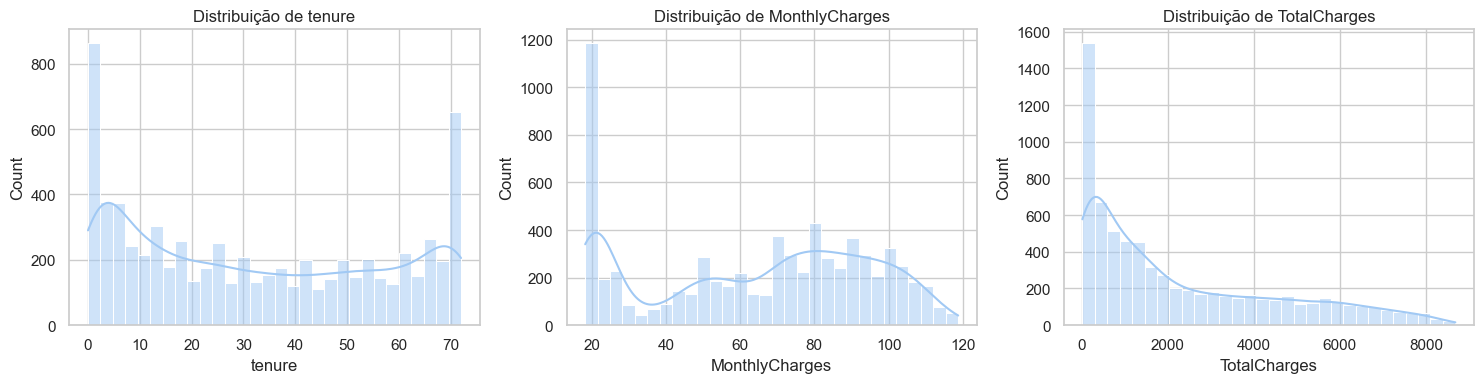

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax, bins=30)
    ax.set_title(f"Distribuição de {col}")
plt.tight_layout()
plt.show()

**Observações:**

- `tenure`: distribuição **bimodal** — muitos clientes muito novos (0–6 meses) e muitos muito antigos (>60 meses). Pouca densidade no meio.
- `MonthlyCharges`: distribuição multimodal, com picos nas faixas de planos populares. Reflete a estrutura de pacotes da operadora.
- `TotalCharges`: cauda longa à direita — clientes antigos com altos valores acumulados.

---
## 6. Análise univariada — variáveis categóricas

Quantos níveis tem cada categórica e como se distribuem.

In [9]:
categorical_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c]) and c not in ("customerID", "Churn")]
print(f"Total de categóricas: {len(categorical_cols)}")
print(categorical_cols)

Total de categóricas: 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


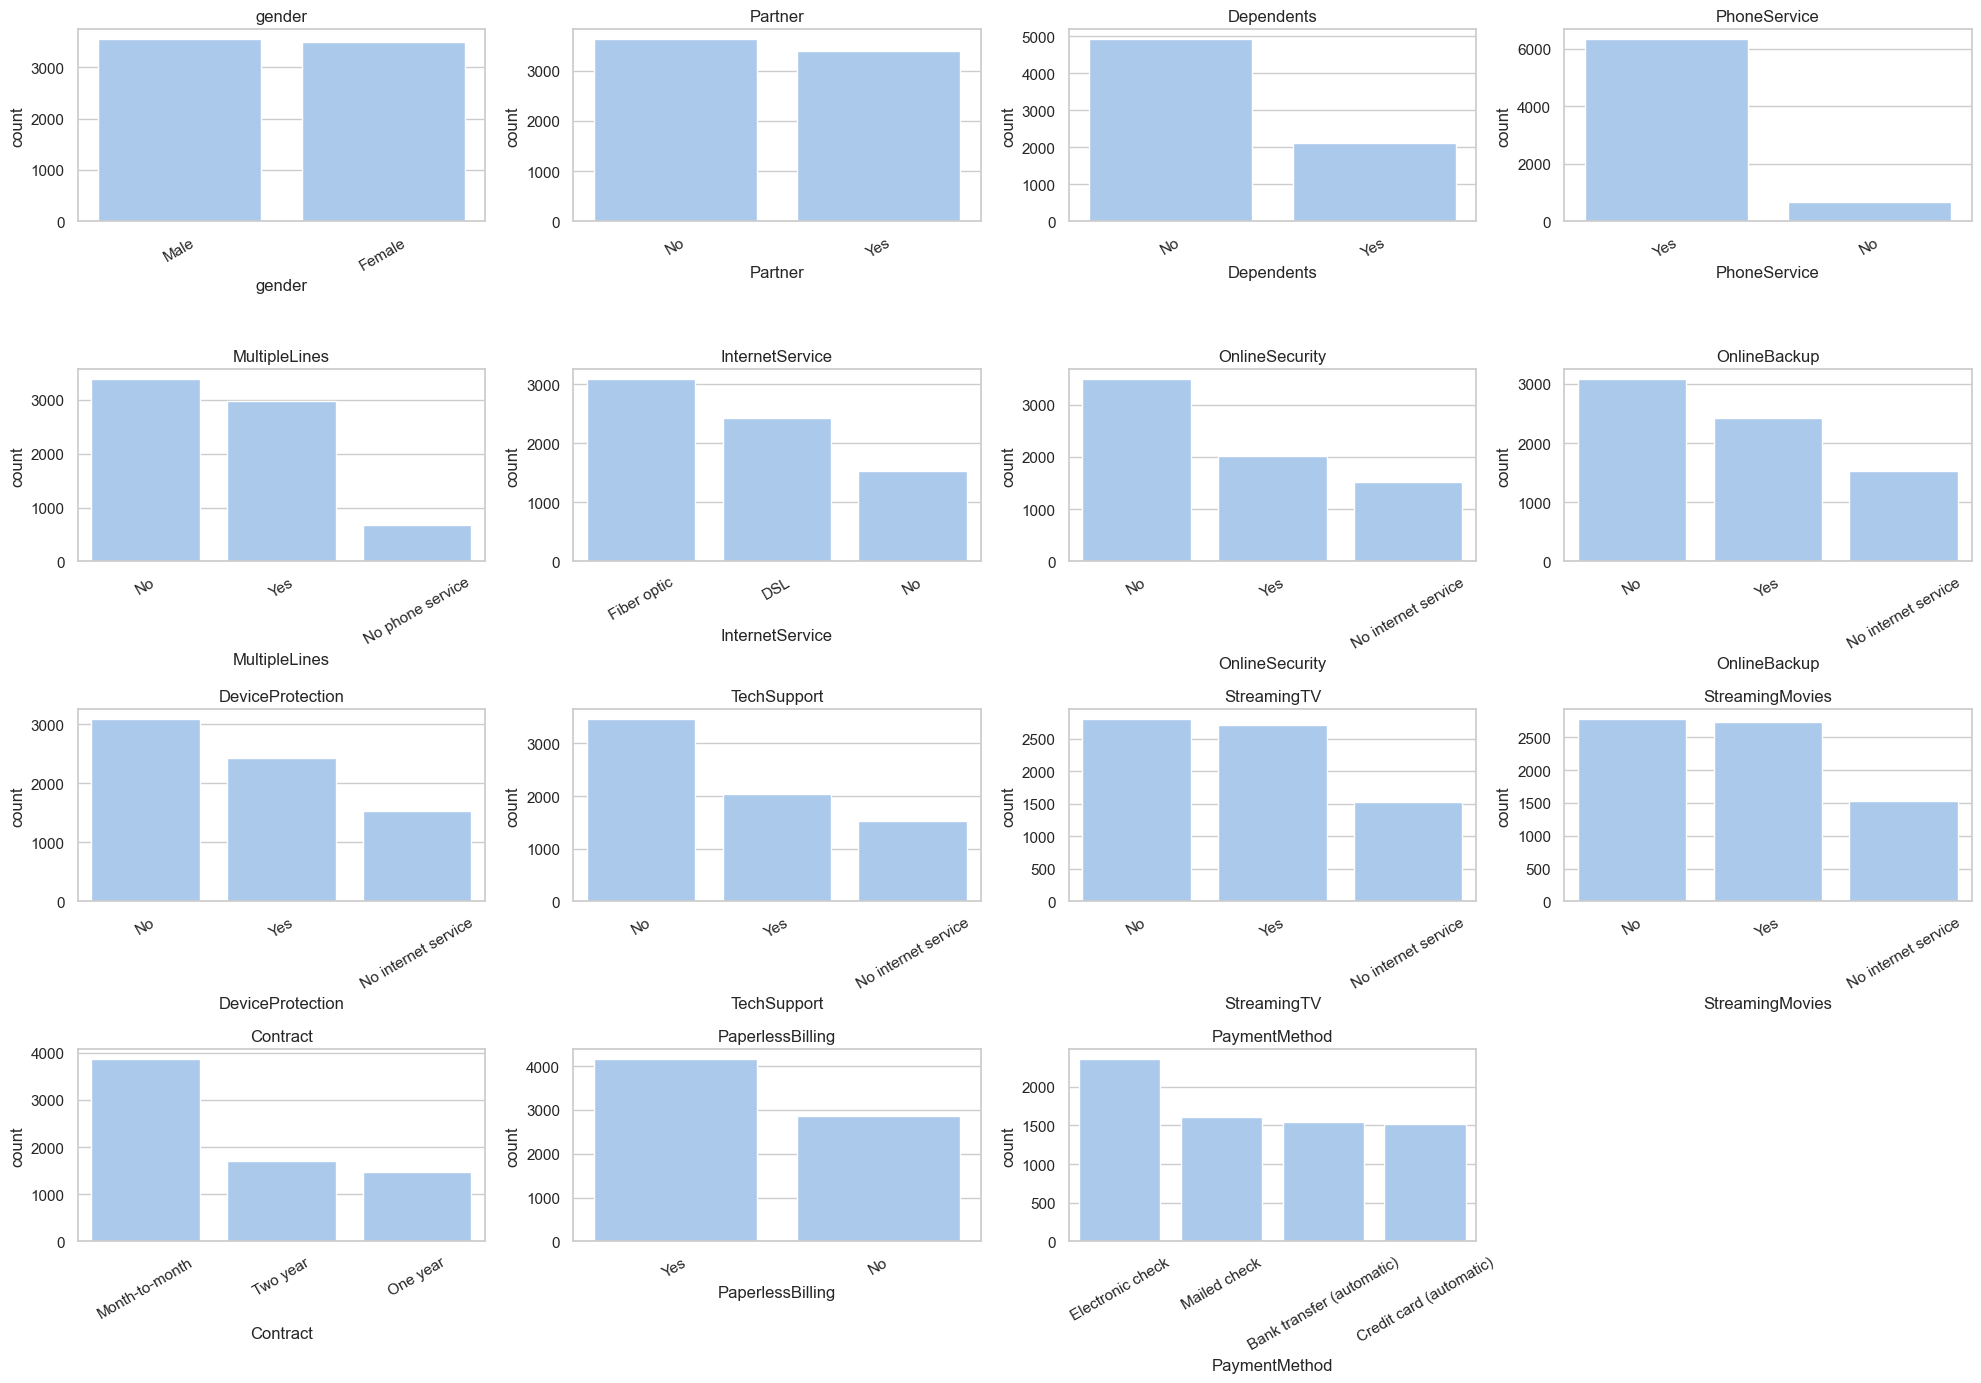

In [10]:
n_cols = 4
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=30)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

---
## 7. Análise bivariada — quem tende a fazer churn?

Esta é a parte mais importante da EDA: **identificar os drivers de churn**.

Para cada categoria, calculamos a taxa de churn — quanto maior o desvio em relação à média global (~26,5%), mais discriminante é a feature.

In [11]:
# Codifica Churn como 0/1 para facilitar o cálculo de taxa
df["churn_flag"] = (df["Churn"] == "Yes").astype(int)
global_churn_rate = df["churn_flag"].mean()
print(f"Taxa global de churn: {global_churn_rate:.1%}")

Taxa global de churn: 26.5%


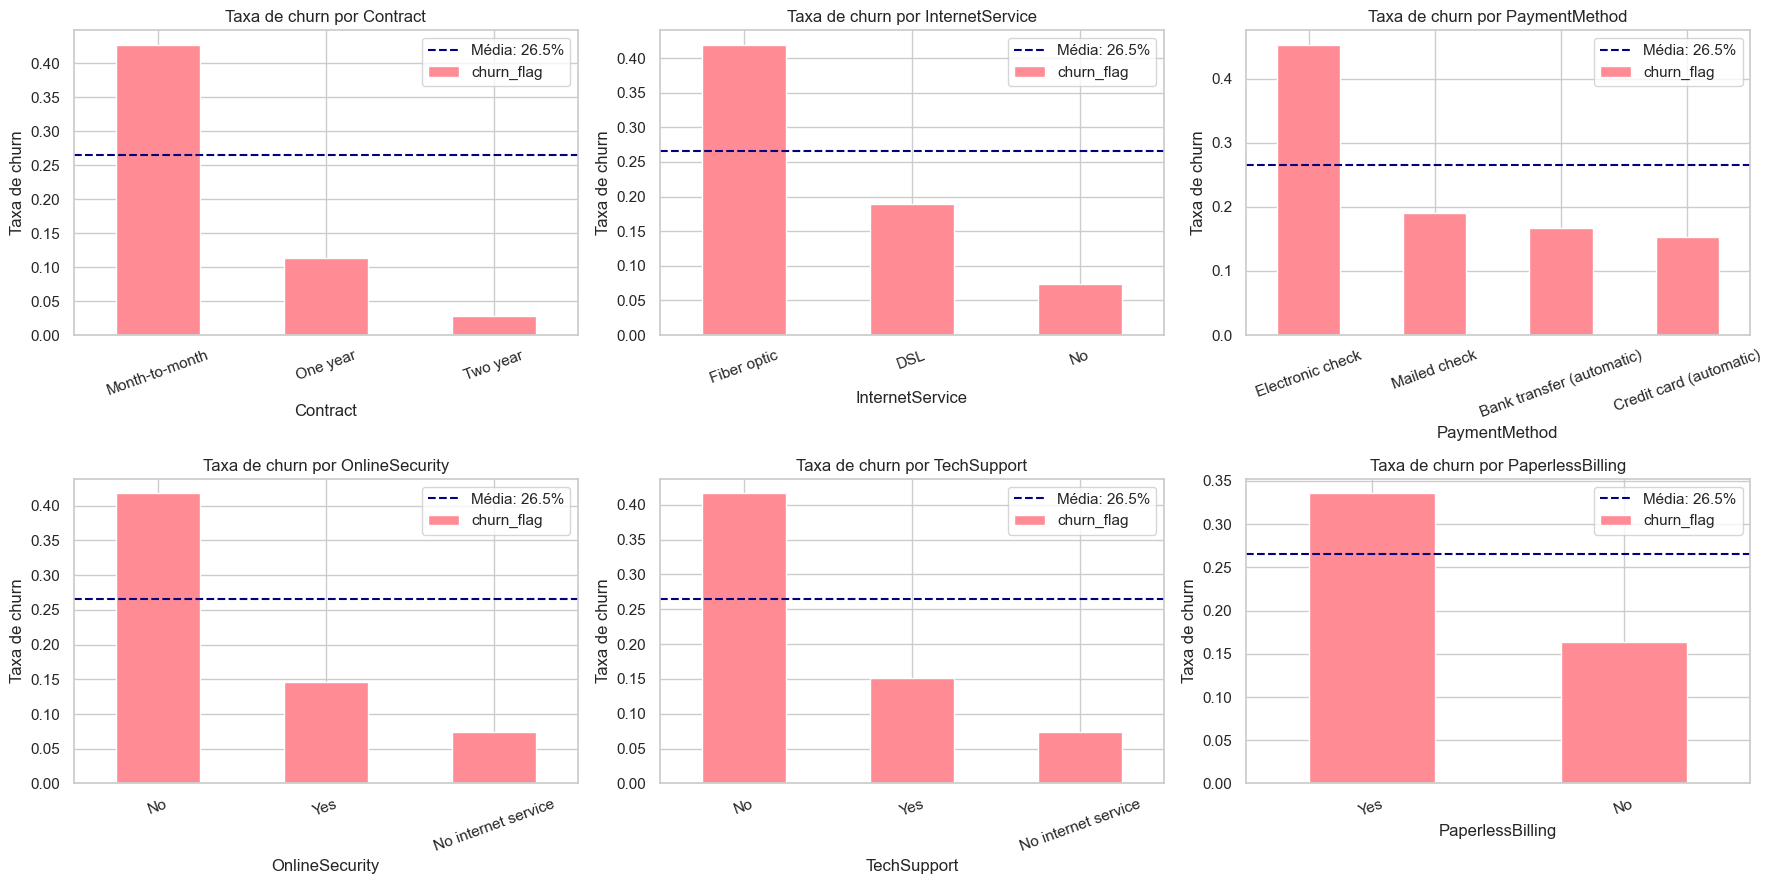

In [12]:
# Features mais relevantes para investigar primeiro (hipótese de negócio)
key_features = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport", "PaperlessBilling"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(key_features):
    rate = df.groupby(col)["churn_flag"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=axes[i], color="#FF8B94")
    axes[i].axhline(global_churn_rate, color="navy", linestyle="--", label=f"Média: {global_churn_rate:.1%}")
    axes[i].set_title(f"Taxa de churn por {col}")
    axes[i].set_ylabel("Taxa de churn")
    axes[i].tick_params(axis="x", rotation=20)
    axes[i].legend()
plt.tight_layout()
plt.show()

**Insights de negócio (hipóteses a confirmar com o modelo):**

- **Contract** é o maior diferenciador: contratos `Month-to-month` têm taxa de churn muito acima da média; `Two year` é muito abaixo. → Estratégia óbvia de retenção: incentivar migração para planos longos.
- **InternetService = Fiber optic** churna mais que DSL. Pode indicar insatisfação com qualidade/preço da fibra.
- **PaymentMethod = Electronic check** churna muito mais que outros métodos — possivelmente clientes menos engajados/automatizados.
- **Sem OnlineSecurity / TechSupport** → maior churn. Serviços de proteção criam stickiness.

### 7.1 Variáveis numéricas vs Churn

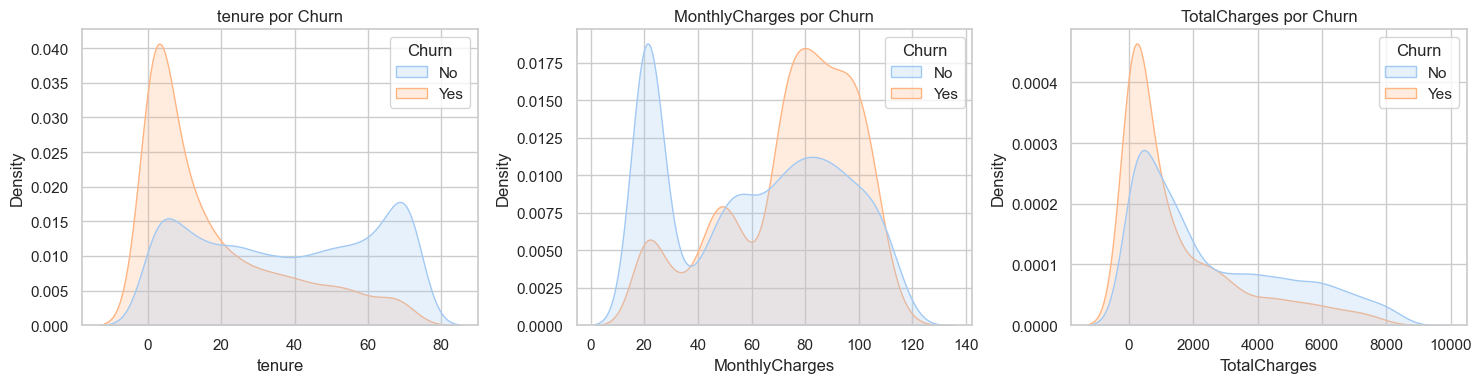

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df, x=col, hue="Churn", common_norm=False, ax=ax, fill=True)
    ax.set_title(f"{col} por Churn")
plt.tight_layout()
plt.show()

**Insight crítico — `tenure`:** clientes que fazem churn estão fortemente concentrados nos primeiros meses (0–10). Isso confirma que **os primeiros meses são o momento de maior risco** — janela de ouro para ações de retenção (onboarding bem feito, ofertas iniciais, etc.).

**MonthlyCharges:** clientes que saem tendem a pagar mais — provavelmente porque assinaram mais serviços (fibra, streaming) e percebem o custo como alto.

---
## 8. Correlações entre variáveis numéricas

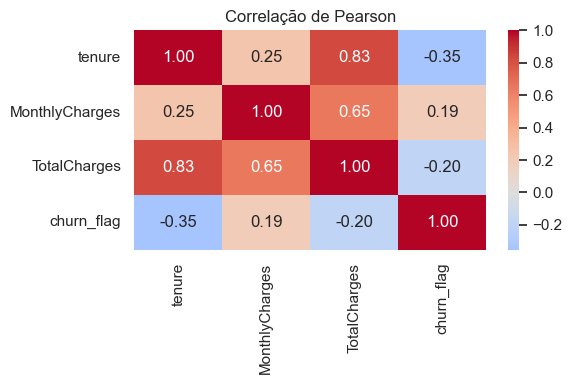

In [14]:
corr = df[numeric_cols + ["churn_flag"]].corr()
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=ax, fmt=".2f")
ax.set_title("Correlação de Pearson")
plt.tight_layout()
plt.show()

**Observação:** `tenure` e `TotalCharges` são fortemente correlacionados (~0.83) — fazem parte da mesma história (quanto mais tempo, mais pago acumulado). Já temos um possível alerta de **multicolinearidade** para modelos lineares — pode ser necessário tratar (drop ou regularização).

---
## 9. Mapeamento métrica de negócio → métrica técnica

Esta é uma das exigências explícitas do guia do datathon.

### Métrica de negócio

**Reduzir o número de clientes que fazem churn** (especialmente nos primeiros meses, onde o LTV ainda não compensou o custo de aquisição).

### Custo dos erros do modelo

| Tipo de erro | Significado | Custo |
|---|---|---|
| Falso negativo (FN) | Cliente vai sair, modelo diz que fica | **Alto** — perde-se o cliente sem nem tentar reter |
| Falso positivo (FP) | Cliente vai ficar, modelo diz que sai | **Baixo** — gasta-se um cupom/contato com quem ficaria |

### Métrica técnica escolhida: **Recall da classe positiva (churn=Yes)**, com F1 e AUC como suporte

**Justificativa:**

- Como o custo de FN é muito maior que de FP, queremos **maximizar a captura dos clientes em risco**
- Recall isolado pode levar a um modelo "otimista demais" (manda tudo pra retenção) — por isso reportamos também F1 (equilíbrio com precision) e AUC (qualidade do ranking)
- **Acurácia será reportada apenas como referência**, nunca como métrica primária — dado o desbalanceamento

### Trade-off operacional

O modelo entrega uma **probabilidade de churn**. O time de retenção pode ajustar o threshold conforme o budget de campanha:

- Threshold baixo (ex.: 0.3) → mais clientes acionados, mais recall, mais custo
- Threshold alto (ex.: 0.7) → foco em alto risco, mais precision, menos custo

Isso vai ser exposto pelo agente LLM (Etapa 2) como tool: o agente pode pedir o score e raciocinar sobre a melhor ação dado o perfil do cliente.

---
## 10. Conclusões e próximos passos

### Resumo dos achados

1. Dataset limpo após tratar `TotalCharges`, sem outras inconsistências graves
2. Problema moderadamente desbalanceado (26,5% churn) — métrica primária = **recall**, com F1 e AUC de suporte
3. Drivers principais identificados: **Contract**, **tenure**, **InternetService**, **PaymentMethod**, **OnlineSecurity**, **TechSupport**
4. Janela crítica: primeiros meses de relacionamento
5. Multicolinearidade entre `tenure` e `TotalCharges` — atenção em modelos lineares

### Próximos passos (Etapa 1 continua)

- [ ] Implementar `src/features/feature_engineering.py` com:
  - Conversão de `TotalCharges` para numérico
  - Encoding das categóricas (binário e one-hot)
  - Features derivadas (`avg_monthly_spend`, `services_count`, `tenure_bucket`)
- [ ] Treinar baseline em `src/models/train.py` com MLflow tracking
  - Modelo 1: Regressão Logística (referência simples)
  - Modelo 2: Random Forest (modelo principal — interpretável e robusto)
- [ ] Comparar métricas no MLflow UI e escolher o **champion**
- [ ] Versionar dados com DVC